<h1> <font color='blue'> <center> CVEN 5370:GIS Applications in Civil Engineering

<h2> <font color='teal'> <center> Mini Project 1

<h3> <font color='red'> <center> Prabin Kharel.

<hr>

<h4> Problem Statement

Using the National Bridge Inventory Data for Texas for the years 2022 and 2023 the goal of this project is to develop a logistic regression model to predict the probability of a bridge being rated unsatisfactory using other bridge features as inputs.  The NBI data are available from:   <a href="https://www.fhwa.dot.gov/bridge/mtguide.cfm">FHWA Website</a>.  In particular, the bridges evaluated in the year 2022 are used to train the data and the new bridges evaluated in 2023 are used to test the model.

<h4> Workflow

<ol>
<li> Download the data (TX2022 and TX2023.csv) and read them using pandas </li>
<li> Subset variables of interest and pre-process (e.g. lat-lon specification) </li>
<li> Recode the 10 point scale classification to a binary classification (Ratings 0 - 5 (unsatifactory) and 6 and above satisfactory.  These are the outputs to the model </li>
<li> Identify the salient parameters of interest (Inputs and Outputs) based on literature review </li>
<li> Create the training dataset (this is 2022 data)</li>
<li> Create the testing dataset (this is the dataset that has bridges evaluated in 2023 but not in 2022)</li>
<li> Fit the LR model using the training data </li>
<li> Predict the results for the testing data </li>
<li> Make requisite maps and visualize the results </li>
<li> Interpret the results and discuss </li>
<ol>

<h4> Code

<h5> Load Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm
from matplotlib import pyplot as plt
import matplotlib_map_utils as mu
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score

<h5> Set Working Directory

In [3]:
dirx = 'D:/GIS QSN 3/Winter/Miniproj1'
os.chdir(dirx)

<h5> Read Files

In [4]:
fname1 = 'TX22.txt'
fname2 = 'TX23.txt'
fname3 = 'TXDissolved.gpkg'
a = pd.read_csv(fname1,low_memory=False)
b = pd.read_csv(fname2,low_memory=False)
Tx = gpd.read_file(fname3)


<h5> Input Parameter Selection

The input parameters were selected based on the following study:

<font color='blue'>Lu, P., Wang, H., & Tolliver, D. (2019). Prediction of bridge component ratings using ordinal logistic regression model. Mathematical Problems in Engineering, 2019(1), 9797584.</font>
The paper can be <a href="https://onlinelibrary.wiley.com/doi/pdf/10.1155/2019/9797584">downloaded here</a>.

The selected parameters include:

<ul> <li><b>Age:</b> Calculated as 2024 minus the year of construction or year of improvement</li> <li><b>ADT (Average Daily Traffic):</b> Used as provided; not adjusted for a specific reference year</li> <li><b>Deck Area:</b> Total surface area of the bridge deck</li> <li><b>Material Type:</b> Coded as Steel (1), Concrete (2), or Other (3)</li> </ul>

<h5> Pre-Process and Subset Data for Analysis

In [5]:
# Make a listing of all variables in the dataframe (
#for i in a.columns:
#    print(i)

The following variables were chosen as inputs for data visualization and model development: STRUCTURE_NUMBER_008, LAT_016, LONG_017, YEAR_BUILT_027, ADT_029, YEAR_RECONSTRUCTED_106, and DECK_AREA.

The output variables included: 
DECK_COND_058, SUPERSTRUCTURE_COND_059, SUBSTRUCTURE_COND_060, and CULVERT_COND_062. These condition ratings were simplified into binary classes by recoding values 0 to 5 as 0 (unsatisfactory) and above 5 as 1 (satisfactory).

For demonstration purposes, the LOWEST_RATING among the condition variables was used as the output in this analysis.

In [8]:
subset = ['STRUCTURE_NUMBER_008', 'LAT_016', 'LONG_017', 'YEAR_BUILT_027', 'ADT_029', 
          'YEAR_RECONSTRUCTED_106', 'DECK_AREA','LOWEST_RATING']
asub = a[subset]
asub.head()

,STRUCTURE_NUMBER_008,LAT_016,LONG_017,YEAR_BUILT_027,ADT_029,YEAR_RECONSTRUCTED_106,DECK_AREA,LOWEST_RATING
0,0000000L2015318,35185702,101560762,2008,100,0.0,145.50,7
1,000021521-00101,29362100,94272880,2005,1,0.0,150.72,7
2,000021521-00181,29362940,94254920,2005,1,0.0,74.40,7
3,000021521-TMP20,29365160,94324020,2012,100,0.0,91.91,8
4,000021525-00012,29413300,94044860,1950,80,2007.0,204.30,4


In [9]:
bsub = b[subset]
bsub.head()

,STRUCTURE_NUMBER_008,LAT_016,LONG_017,YEAR_BUILT_027,ADT_029,YEAR_RECONSTRUCTED_106,DECK_AREA,LOWEST_RATING
0,0000000L2015318,35185702,101560762,2008,100,0.0,169.84,7
1,000021521-00101,29362100,94272880,2005,1,0.0,150.72,6
2,000021521-00181,29362940,94254920,2005,1,0.0,74.40,7
3,000021521-TMP20,29365160,94324020,2012,100,0.0,91.91,7
4,000021525-00012,29413300,94044860,1950,80,2007.0,204.30,4


<h5> Compute Model Parameters

In [10]:
# Compute Age Variable
asub = asub.copy()
asub['Age'] = 2024 - asub[['YEAR_BUILT_027', 'YEAR_RECONSTRUCTED_106']].max(axis=1)
bsub = bsub.copy()
bsub['Age'] = 2024 - bsub[['YEAR_BUILT_027', 'YEAR_RECONSTRUCTED_106']].max(axis=1)

In [11]:
# Reclassify the Bridge lowest Indicators (unknown conditions are assumed to be unsatisfactory for conservativeness)
asub['Bridgereclass']=  np.where(pd.to_numeric(asub['LOWEST_RATING'], errors='coerce') > 5,1,0)
bsub['Bridgereclass']=  np.where(pd.to_numeric(bsub['LOWEST_RATING'], errors='coerce') > 5,1,0)

<h5> Additional Pre-Processing

In [12]:
# Convert lat-lon to decimal degrees with correct units
def convert_long(long,idx):
    # Convert the integer to a string
    long_str = str(long)   
    # Determine the number of digits for degrees based on length (8 or 9)
    if len(long_str) == 8:
        degrees = int(long_str[:2])
        minutes = int(long_str[2:4])
        seconds = int(long_str[4:]) / 10000  # Divide seconds by 10000 to get decimal seconds
    elif len(long_str) == 9:
        degrees = int(long_str[:3])
        minutes = int(long_str[3:5])
        seconds = int(long_str[5:]) / 10000
    # Calculate decimal degrees
    decimal_degrees = degrees + minutes / 60 + seconds / 3600
    if(idx == 'LON'):
        decimal_degrees = decimal_degrees * -1
    return decimal_degrees

conlatlon = np.vectorize(convert_long)


In [15]:
asub['latdd'] = conlatlon(asub.LAT_016,"LAT")
asub['londd'] = conlatlon(asub.LONG_017,'LON')
bsub['latdd'] = conlatlon(bsub.LAT_016,"LAT")
bsub['londd'] = conlatlon(bsub.LONG_017,'LON')


In [16]:
# Remove briges with low traffic - likely to be in satisfactory state due to this condition
asub = asub.loc[asub['ADT_029']>10]
bsub = bsub.loc[bsub['ADT_029']>10]

<h5> Obtain Unique Bridges for 2023 (not sampled in 2022)

In [17]:
csub = bsub.merge(asub,on= 'STRUCTURE_NUMBER_008',how='left',indicator=True)
csub1 = csub[csub['_merge'] == 'left_only'].drop(columns=['_merge'])
csub2 = csub1.dropna(axis=1)
csub2.head()

,STRUCTURE_NUMBER_008,LAT_016_x,LONG_017_x,YEAR_BUILT_027_x,ADT_029_x,DECK_AREA_x,LOWEST_RATING_x,Age_x,Bridgereclass_x,latdd_x,londd_x
10,010000000033465,30305851,95042675,2020,100,144.57,8,4.0,1,30.500163,-95.066741
11,010600013603019,33184173,95492402,1930,5695,98.60,6,8.0,1,33.300116,-95.816733
12,010600013603026,33200659,95460114,1934,4433,116.62,7,7.0,1,33.333352,-95.766670
13,010600013603028,33214527,95432058,1934,5168,584.24,5,65.0,0,33.350126,-95.716724
14,010600013603083,33225759,95413327,1967,4702,142.71,6,57.0,1,33.366827,-95.683426


In [18]:
# Get a final tally of all Bridges
print('Bridges in 2022 used for Training:',len(asub))
print('Unique Bridges of 2023 for Testing:',len(csub2))

Bridges in 2022 used for Training: 55288
Unique Bridges of 2023 for Testing: 12272


<h5> Visualize Locations of Training and Testing Datasets

In [19]:
# Convert to GeoDataFrame
# Step 1: Create a geometry column using the latitude and longitude
geometry = [Point(xy) for xy in zip(asub['londd'], asub['latdd'])]
# Step 2: Convert the DataFrame to a GeoDataFrame
Br2022 = gpd.GeoDataFrame(asub, geometry=geometry)
# Step 3: Set the coordinate reference system (CRS) to WGS84 (EPSG:4326)
Br2022.set_crs(epsg=4326, inplace=True)

# Convert to GeoDataFrame
# Step 1: Create a geometry column using the latitude and longitude
geometry = [Point(xy) for xy in zip(csub2['londd_x'], csub2['latdd_x'])]
# Step 2: Convert the DataFrame to a GeoDataFrame
Br2023u = gpd.GeoDataFrame(csub2, geometry=geometry)
# Step 3: Set the coordinate reference system (CRS) to WGS84 (EPSG:4326)
Br2023u.set_crs(epsg=4326, inplace=True)


,STRUCTURE_NUMBER_008,LAT_016_x,LONG_017_x,YEAR_BUILT_027_x,ADT_029_x,DECK_AREA_x,LOWEST_RATING_x,Age_x,Bridgereclass_x,latdd_x,londd_x,geometry
10,010000000033465,30305851,95042675,2020,100,144.57,8,4.0,1,30.500163,-95.066741,POINT (-95.06674 30.50016)
11,010600013603019,33184173,95492402,1930,5695,98.60,6,8.0,1,33.300116,-95.816733,POINT (-95.81673 33.30012)
12,010600013603026,33200659,95460114,1934,4433,116.62,7,7.0,1,33.333352,-95.766670,POINT (-95.76667 33.33335)
13,010600013603028,33214527,95432058,1934,5168,584.24,5,65.0,0,33.350126,-95.716724,POINT (-95.71672 33.35013)
14,010600013603083,33225759,95413327,1967,4702,142.71,6,57.0,1,33.366827,-95.683426,POINT (-95.68343 33.36683)
...,...,...,...,...,...,...,...,...,...,...,...,...
55876,DAPFORHOO0BVM20,31091962,97485846,2023,100,6207.60,8,1.0,1,31.150054,-97.800162,POINT (-97.80016 31.15005)
55888,NCA1,32430233,96561253,1988,96,341.28,6,36.0,1,32.716673,-96.933368,POINT (-96.93337 32.71667)
55889,NCA2,32424987,96560305,1998,96,141.68,5,26.0,0,32.700139,-96.933342,POINT (-96.93334 32.70014)
55890,NCA3,32424560,96561340,1998,96,364.81,6,26.0,1,32.700127,-96.933371,POINT (-96.93337 32.70013)


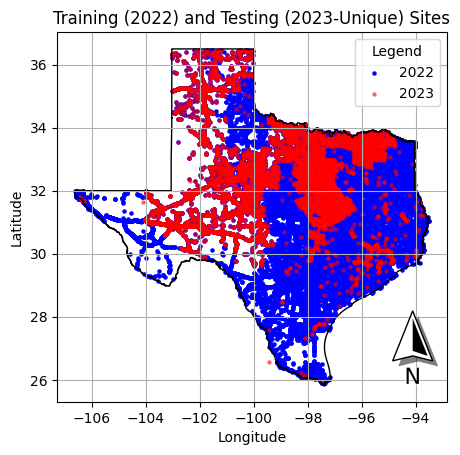

In [20]:
# Plot the GeoDataFrame
fig,ax = plt.subplots()
Br2022.plot(ax=ax,marker='o', color='blue', markersize=5,label='2022')
Br2023u.plot(ax=ax,marker='o',color='red',markersize=5,alpha=0.5,label='2023')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.legend(title="Legend", loc='upper right')
mu.north_arrow.north_arrow(ax=ax,location='lower right',rotation={"degrees":0})
plt.grid()
Tx.plot(ax=ax,color='none',edgecolor='black')
plt.title('Training (2022) and Testing (2023-Unique) Sites')
plt.show()

<h5> Perform Logistic Regression

In [24]:
asub.columns

Index(['STRUCTURE_NUMBER_008', 'LAT_016', 'LONG_017', 'YEAR_BUILT_027',
       'ADT_029', 'YEAR_RECONSTRUCTED_106', 'DECK_AREA', 'LOWEST_RATING',
       'Age', 'Bridgereclass', 'latdd', 'londd'],
      dtype='object')

In [25]:
# Define independent variables (X) and dependent variable (y) for training data

X = asub[['ADT_029', 'DECK_AREA','Age']]  # Predictor variables
y = asub['Bridgereclass']     # Outcome variable

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit(maxiter=100)

Optimization terminated successfully.
         Current function value: 0.285599
         Iterations 7


In [26]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:          Bridgereclass   No. Observations:                55288
Model:                          Logit   Df Residuals:                    55284
Method:                           MLE   Df Model:                            3
Date:                Thu, 10 Apr 2025   Pseudo R-squ.:                 0.08456
Time:                        09:37:53   Log-Likelihood:                -15790.
converged:                       True   LL-Null:                       -17249.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9840      0.042     93.892      0.000       3.901       4.067
ADT_029     3.952e-08   7.41e-07      0.053      0.957   -1.41e-06    1.49e-06
DECK_AREA  -5.322e-05   4.51e-06    -11.808      0.000    -6.2e-05   -4.44e-05
Age           -0.0365      0.001    -50.826      0.000      -0.038      -0.035
==============================================================================
"""

In [27]:
# Predict binary outcome (e.g., 0 or 1) based on threshold (e.g., 0.5)
predicted_probabilities = result.predict(X)
cutoff = 0.9  # Higher cut-off is necessary because the dataset is imbalanced (more 1 than 0)
predicted_outcome = (predicted_probabilities >= cutoff).astype(int)
# Create Contingency Table (Confusion Matrix)
conf_matrix = confusion_matrix(y, predicted_outcome)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[ 3350  1854]
 [17393 32691]]


ADT is not statistically significant, the rescaling of the parameters would help improve the model fit.

In [28]:
X_test = csub2[['ADT_029_x','DECK_AREA_x','Age_x']]
y_test = csub2['Bridgereclass_x']
# Add a constant (intercept) to the model
X_test = sm.add_constant(X_test)
# Predict probabilities on the testing data
predicted_probabilities = result.predict(X_test)
predicted_outcome = (predicted_probabilities >= cutoff).astype(int)

# Create Contingency Table (Confusion Matrix)
conf_matrix = confusion_matrix(y_test, predicted_outcome)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[ 798  234]
 [5029 6211]]


<h5> Model Evaluation

In [29]:
# Create Contingency Table (Confusion Matrix)
conf_matrix = confusion_matrix(y_test, predicted_outcome)
print("Confusion Matrix:\n", conf_matrix)

#Calculate Model Fit Metrics
accuracy = accuracy_score(y_test, predicted_outcome)
precision = precision_score(y_test, predicted_outcome)
recall = recall_score(y_test, predicted_outcome)
roc_auc = roc_auc_score(y_test, predicted_probabilities)

print("\nModel Fit Metrics:")
print("Accuracy:", round(accuracy,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("ROC-AUC Score:", round(roc_auc,3))

Confusion Matrix:
 [[ 798  234]
 [5029 6211]]

Model Fit Metrics:
Accuracy: 0.571
Precision: 0.964
Recall: 0.553
ROC-AUC Score: 0.732


<h4> Risk Visualization

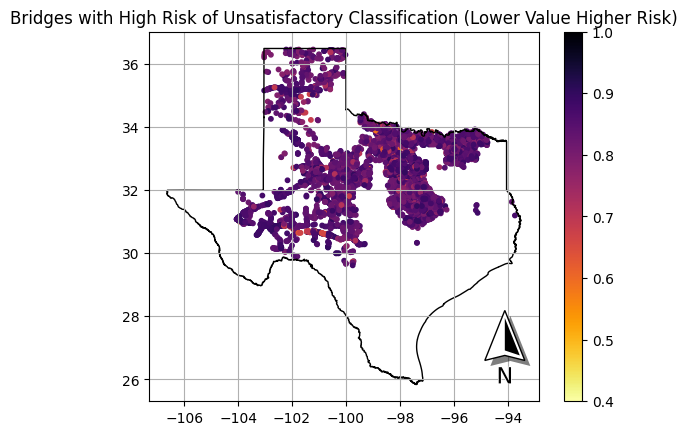

In [30]:
# Add predicted probs to the Br2023u geodataframe
Br2023u['prob'] = predicted_probabilities
Br2023r = Br2023u[Br2023u['prob']<= cutoff]
fig,ax = plt.subplots()
Br2023r.plot(ax=ax,column=Br2023r['prob'], cmap='inferno_r', legend=True, markersize=10, vmin=0.4, vmax=1.0)
Tx.plot(ax=ax,color='none',edgecolor='black')
plt.title('Bridges with High Risk of Unsatisfactory Classification (Lower Value Higher Risk)')
plt.grid()
mu.north_arrow.north_arrow(ax=ax,location='lower right',rotation={"degrees":0})
plt.show()

<h4> Discussion

The model does a good job identifying bridges that are likely to be rated as unsatisfactory. However, due to the imbalance in the dataset, a higher probability threshold is needed to accurately classify these sites.